In [16]:
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame

In [17]:
def crop(Image, offsetHauteur, offsetLargeur):
    hauteur = Image.shape[0]
    largeur = Image.shape[1]
    croped_image = Image[(hauteur//2 -offsetHauteur):(hauteur//2 +offsetHauteur),(largeur//2 -offsetLargeur):(largeur//2 +offsetLargeur)]
    return croped_image

In [18]:
def extractImages(pathIn, pathOut):
    count = 0
    vidcap = cv2.VideoCapture(pathIn)
    print(pathIn)
    vid= pathIn.split("/")[2].split(".")[0]
    success,image = vidcap.read()
    success = True
    while success:
        vidcap.set(cv2.CAP_PROP_POS_MSEC,(count*500))
        success,image = vidcap.read()
        if(success != False):            
            image = crop(image,200,200)
            cv2.imwrite(pathOut + "/" + vid+"-%d.jpg" % count, image)
            print("frame "+vid+"-%d.jpg" % count,success)
        count = count + 1

In [19]:
video_path = "./video"
video_names = os.listdir(video_path)
print(video_names)
len(video_names)

['rl1_pb12-4.mp4', 'rl1_pb17-4.mp4', 'rl1_pb19-4.mp4', 'rl1_pb2-4..mp4', 'rl1_pb30-4.mp4', 'rl1_pb4-4.mp4', 'rl1_pb9-4.mp4', 'rl3_pb12-4.mp4', 'rl3_pb16-4.mp4', 'rl3_pb19-4.mp4', 'rl3_pb30-4.mp4', 'rl3_pb4-4.mp4', 'rl3_pb9-4.mp4', 'rl3_pb9-5.mp4', 'rl4_pb09_05_2022-1_Trim.mp4', 'rl4_pb16-4.mp4', 'rl4_pb17-4.mp4', 'rl4_pb19-4.mp4', 'rl4_pb2-4..mp4', 'rl4_pb20_04_2022-2.mp4', 'rl4_pb20_04_2022-3.mp4', 'rl4_pb23-4.mp4', 'rl4_pb25_05_2022-10.mp4', 'rl4_pb25_05_2022-7.mp4', 'rl4_pb25_05_2022-9.mp4', 'rl4_pb26_05_2022-2.mp4', 'rl4_pb26_05_2022-6.mp4', 'rl4_pb27_04_2022-1.mp4', 'rl4_pb30-4.mp4', 'rl4_pb4-4.mp4', 'rl4_pb8-7.mp4', 'rl4_pb9-4.mp4', 'rl4_pb9-5.mp4']


33

In [28]:
cur_path = "./video"
save_path="./train_resizedimages"

video_names = os.listdir(cur_path)
i=1
for video_name in video_names:
    cur_path_vid = cur_path + "/" + video_name
    extractImages(cur_path_vid , save_path)
    i = i + 1
    print(i)

./video/rl1_pb12-4.mp4
frame rl1_pb12-4-0.jpg True
frame rl1_pb12-4-1.jpg True
frame rl1_pb12-4-2.jpg True
frame rl1_pb12-4-3.jpg True
frame rl1_pb12-4-4.jpg True
frame rl1_pb12-4-5.jpg True
frame rl1_pb12-4-6.jpg True
frame rl1_pb12-4-7.jpg True
frame rl1_pb12-4-8.jpg True
frame rl1_pb12-4-9.jpg True
frame rl1_pb12-4-10.jpg True
frame rl1_pb12-4-11.jpg True
frame rl1_pb12-4-12.jpg True
frame rl1_pb12-4-13.jpg True
frame rl1_pb12-4-14.jpg True
frame rl1_pb12-4-15.jpg True
frame rl1_pb12-4-16.jpg True
frame rl1_pb12-4-17.jpg True
frame rl1_pb12-4-18.jpg True
frame rl1_pb12-4-19.jpg True
frame rl1_pb12-4-20.jpg True
frame rl1_pb12-4-21.jpg True
frame rl1_pb12-4-22.jpg True
frame rl1_pb12-4-23.jpg True
frame rl1_pb12-4-24.jpg True
frame rl1_pb12-4-25.jpg True
frame rl1_pb12-4-26.jpg True
frame rl1_pb12-4-27.jpg True
frame rl1_pb12-4-28.jpg True
frame rl1_pb12-4-29.jpg True
frame rl1_pb12-4-30.jpg True
frame rl1_pb12-4-31.jpg True
frame rl1_pb12-4-32.jpg True
frame rl1_pb12-4-33.jpg True
f

In [28]:
def prepareFileTrainAugm():
    writer = pd.ExcelWriter('./data_train_augm_Pb.xlsx', engine = 'xlsxwriter')
    # load the test dataset pb
    test_path = "./train_resizedimages"
    test_names = os.listdir(test_path)

    file_name = 'DataSource.xlsx' # name of your excel file
    
    df = read_excel(file_name, sheet_name = 'Relavage 4')
    name_video=df["points"]
    Analyses = {"points": [],
        "Cu (%)": [],
        "Fe (%)": [],
        "Pb (%)": [],
        "Zn (%)": []
    }

    for video in name_video:
        df_row= df[df['points']== video ]
        if not "-" in video:
            break
        video_0, video_1 = video.split(".")[0].split("-")
        for test_name in test_names:
            if(test_name != "desktop.ini"):
                train_0, train_1, _ = test_name.split(".")[0].split("-")
                if(video_0 == train_0)and (video_1 == train_1):
                    Analyses["points"].append(test_name)
                    Analyses["Cu (%)"].append(df_row["Cu (%)"].to_string(index=False))
                    Analyses["Fe (%)"].append(df_row["Fe (%)"].to_string(index=False))
                    Analyses["Pb (%)"].append(df_row["Pb (%)"].to_string(index=False))
                    Analyses["Zn (%)"].append(df_row["Zn (%)"].to_string(index=False))
    df_Cu = DataFrame(Analyses, columns= ['points', 'Cu (%)', 'Fe (%)', 'Pb (%)', 'Zn (%)']) 
    
    for i in range(0,df_Cu.shape[0]):
        cu = float(df_Cu.iloc[i]['Cu (%)'])
        fe = float(df_Cu.iloc[i]['Fe (%)'])
        pb = float(df_Cu.iloc[i]['Pb (%)'])
        zn = float(df_Cu.iloc[i]['Zn (%)'])

        
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Cu (%)'] = cu + (ofsset/10)
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Fe (%)'] = fe + (ofsset/10)
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Pb (%)'] = pb + (ofsset/10)
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Zn (%)'] = zn + (ofsset/10)
    
    df_Cu.to_excel(writer, sheet_name = 'Relavage 4', index = None, header=True)
    
    writer.save()
    writer.close()

In [ ]:
prepareFileTrainAugm()

In [3]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage 4')

In [4]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl4_pb2-4-0.jpg,0.880227,2.789825,33.368376,1.657308
1,rl4_pb2-4-1.jpg,0.895511,3.215946,33.232113,1.766720
2,rl4_pb2-4-10.jpg,1.041192,2.538389,32.468759,1.269323
3,rl4_pb2-4-11.jpg,0.821164,3.116522,32.474161,1.619635
4,rl4_pb2-4-12.jpg,0.630280,3.403430,32.979843,0.943100
...,...,...,...,...,...
632,rl4_pb8-7-59.jpg,1.037082,10.282560,50.677916,4.221923
633,rl4_pb8-7-6.jpg,1.258584,9.879502,50.716746,4.627203
634,rl4_pb8-7-7.jpg,1.094279,10.359507,51.150314,4.519175
635,rl4_pb8-7-8.jpg,0.695495,10.532507,50.690492,4.425693


In [5]:
from sklearn.decomposition import PCA
import numpy as np

def image_to_fft_pca(image):
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20*np.log(np.abs(fshift))
    pca = PCA(n_components=1)
    features = pca.fit_transform(magnitude_spectrum)
    features = features.reshape(-1)
    return features

In [6]:
fft_features = []
labels_pb = []

In [7]:
for line in df.values:
    image = cv2.imread("./train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_pb.append(line[3])

In [8]:
fft_features = np.array(fft_features)
labels_pb = np.array(labels_pb)

In [9]:
fft_features.shape

(637, 400)

In [10]:
labels_pb.shape

(637,)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SVM with FFT and PCA

In [12]:
svm = SVR()
svm.fit(fft_features, labels_pb)
# y_pred = svm.predict(X_test)

SVR()

Linear Regression with FFT and PCA

In [13]:
lr = LinearRegression()
lr.fit(fft_features, labels_pb)
# y_pred = lr.predict(X_test)

LinearRegression()

XGBoost with FFT and PCA

In [14]:
xgb = XGBRegressor()
xgb.fit(fft_features, labels_pb)
# y_pred = xgb.predict(X_test)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints='', learning_rate=0.300000012, max_bin=256,
             max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
             max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, ...)

In [21]:
cur_path = "./video_test"
save_path="./test_resizedimages"

video_names = os.listdir(cur_path)
i=1
for video_name in video_names:
    cur_path_vid = cur_path + "/" + video_name
    extractImages(cur_path_vid , save_path)
    i = i + 1
    print(i)

./video_test/rl1_pb16-4.mp4
frame rl1_pb16-4-0.jpg True
frame rl1_pb16-4-1.jpg True
frame rl1_pb16-4-2.jpg True
frame rl1_pb16-4-3.jpg True
frame rl1_pb16-4-4.jpg True
frame rl1_pb16-4-5.jpg True
frame rl1_pb16-4-6.jpg True
frame rl1_pb16-4-7.jpg True
frame rl1_pb16-4-8.jpg True
frame rl1_pb16-4-9.jpg True
frame rl1_pb16-4-10.jpg True
frame rl1_pb16-4-11.jpg True
frame rl1_pb16-4-12.jpg True
frame rl1_pb16-4-13.jpg True
frame rl1_pb16-4-14.jpg True
frame rl1_pb16-4-15.jpg True
frame rl1_pb16-4-16.jpg True
frame rl1_pb16-4-17.jpg True
frame rl1_pb16-4-18.jpg True
frame rl1_pb16-4-19.jpg True
frame rl1_pb16-4-20.jpg True
frame rl1_pb16-4-21.jpg True
frame rl1_pb16-4-22.jpg True
frame rl1_pb16-4-23.jpg True
frame rl1_pb16-4-24.jpg True
frame rl1_pb16-4-25.jpg True
frame rl1_pb16-4-26.jpg True
frame rl1_pb16-4-27.jpg True
frame rl1_pb16-4-28.jpg True
frame rl1_pb16-4-29.jpg True
frame rl1_pb16-4-30.jpg True
frame rl1_pb16-4-31.jpg True
frame rl1_pb16-4-32.jpg True
frame rl1_pb16-4-33.jpg T

In [29]:
def prepareFileTestAugm():
    writer = pd.ExcelWriter('./data_test_augm_Pb.xlsx', engine = 'xlsxwriter')
    # load the test dataset pb
    test_path = "./test_resizedimages"
    test_names = os.listdir(test_path)

    file_name = 'DataSource.xlsx' # name of your excel file
    
    df = read_excel(file_name, sheet_name = 'Relavage 4')
    name_video=df["points"]
    Analyses = {"points": [],
        "Cu (%)": [],
        "Fe (%)": [],
        "Pb (%)": [],
        "Zn (%)": []
    }

    for video in name_video:
        df_row= df[df['points']== video ]
        if not "-" in video:
            break
        video_0, video_1 = video.split(".")[0].split("-")
        for test_name in test_names:
            if(test_name != "desktop.ini"):
                train_0, train_1, _ = test_name.split(".")[0].split("-")
                if(video_0 == train_0)and (video_1 == train_1):
                    Analyses["points"].append(test_name)
                    Analyses["Cu (%)"].append(df_row["Cu (%)"].to_string(index=False))
                    Analyses["Fe (%)"].append(df_row["Fe (%)"].to_string(index=False))
                    Analyses["Pb (%)"].append(df_row["Pb (%)"].to_string(index=False))
                    Analyses["Zn (%)"].append(df_row["Zn (%)"].to_string(index=False))
    df_Cu = DataFrame(Analyses, columns= ['points', 'Cu (%)', 'Fe (%)', 'Pb (%)', 'Zn (%)']) 
    
    for i in range(0,df_Cu.shape[0]):
        cu = float(df_Cu.iloc[i]['Cu (%)'])
        fe = float(df_Cu.iloc[i]['Fe (%)'])
        pb = float(df_Cu.iloc[i]['Pb (%)'])
        zn = float(df_Cu.iloc[i]['Zn (%)'])

        
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Cu (%)'] = cu + (ofsset/10)
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Fe (%)'] = fe + (ofsset/10)
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Pb (%)'] = pb + (ofsset/10)
        ofsset = random.uniform(0,10)
        df_Cu.at[i,'Zn (%)'] = zn + (ofsset/10)
    
    df_Cu.to_excel(writer, sheet_name = 'Relavage 4', index = None, header=True)
    
    writer.save()
    writer.close()

In [30]:
prepareFileTestAugm()

C:\Users\Youssef\AppData\Local\Temp\ipykernel_17180\3008875678.py:52: FutureWarning: save is not part of the public API, usage can give in unexpected results and will be removed in a future version
  writer.save()
c:\Users\Youssef\AppData\Local\Programs\Python\Python39\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


In [34]:
test_file_name = 'data_test_augm_Pb.xlsx'
df_test = read_excel(test_file_name, sheet_name = 'Relavage 4')

In [35]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl4_pb12-4-0.jpg,2.538954,11.389488,49.742996,5.604848
1,rl4_pb12-4-1.jpg,2.111744,11.014405,49.632407,5.927422
2,rl4_pb12-4-10.jpg,1.698484,11.825520,49.908293,6.004048
3,rl4_pb12-4-11.jpg,2.128018,11.077257,49.982189,5.490961
4,rl4_pb12-4-12.jpg,1.669191,11.089730,49.705122,5.840041
...,...,...,...,...,...
132,rl4_pb30-6-60.jpg,2.472194,5.993961,57.880500,1.565985
133,rl4_pb30-6-61.jpg,2.633384,6.433615,58.444728,1.449237
134,rl4_pb30-6-7.jpg,2.420843,6.017722,58.152315,1.870643
135,rl4_pb30-6-8.jpg,2.008681,6.268195,58.737288,1.812645


In [37]:
test_fft_features = []
test_labels_pb = []

In [39]:
for line in df_test.values:
    image = cv2.imread("./test_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    test_fft_features.append(fft_pca)
    test_labels_pb.append(line[3])

In [40]:
test_fft_features = np.array(test_fft_features)
test_labels_pb = np.array(test_labels_pb)

In [41]:
test_fft_features.shape

(137, 400)

In [42]:
test_labels_pb.shape

(137,)

In [47]:
y_pred = svm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels_pb, y_pred))
print("MSE", mean_squared_error(test_labels_pb, y_pred))
print("R2 Score", r2_score(test_labels_pb, y_pred))

MAE 3.932665378323055
MSE 23.855273914405213
R2 Score -0.3910194982987538


In [48]:
y_pred = xgb.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels_pb, y_pred))
print("MSE", mean_squared_error(test_labels_pb, y_pred))
print("R2 Score", r2_score(test_labels_pb, y_pred))

MAE 5.895885717026822
MSE 48.27744021464909
R2 Score -1.815094930684372


In [49]:
y_pred = lr.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels_pb, y_pred))
print("MSE", mean_squared_error(test_labels_pb, y_pred))
print("R2 Score", r2_score(test_labels_pb, y_pred))

MAE 6.185340805458434
MSE 58.466047019742646
R2 Score -2.4092004847533315


In [54]:
def TenneurReel(Video, FileName):
    df = read_excel(FileName, sheet_name = 'Relavage 4')
    CuReel, FeReel, PbReel, ZnReel = 0, 0, 0, 0
    for i in range(0, df.shape[0]):
        if Video == df['points'].values[i]:
            CuReel = df['Cu (%)'].values[i]
            FeReel = df['Fe (%)'].values[i]
            PbReel = df['Pb (%)'].values[i]
            ZnReel = df['Zn (%)'].values[i]
    return CuReel, FeReel, PbReel, ZnReel

In [61]:
TeunneurReel = TenneurReel("rl4_pb30-6.mp4", "DataSource.xlsx")

In [62]:
TeunneurReel

(1.78, 5.89, 57.78, 1.24)

In [ ]:
Teneur_predit = []
Fe = []
Cu = []
Pb = []
Zn = []
count = 0

Video = cv2.VideoCapture("./video_test/rl4_pb30-6.mp4")

while(Video.isOpened()):
    Video.set(cv2.CAP_PROP_POS_MSEC,(count*500))    # added this line 
    
    success, frame = Video.read()
    if success == False:
        break
        #offset 200
    image = crop(frame, 200, 200)
    
        
    #prediction
        #resize 400
    # resized = cv2.resize(image, (200,200), interpolation = cv2.INTER_AREA)
    # resized = resized/255.0
    # resized = np.array(resized)
    # resized = resized.reshape((1,200,200,3))
    
    # apply fft
    fft_pca = image_to_fft_pca(image)
    fft_pca = fft_pca.reshape(1, -1)

    #predict
    t = svm.predict(fft_pca)
    
    #print(t)
    
    Teneur_predit.append(t)
        
    count=count+1

In [80]:
import scipy.stats as stats

In [88]:
def cal_quartil(data):
    data = DataFrame(data)
    #find absolute value of z-score for each observation
    z = np.abs(stats.zscore(data))
    #only keep rows in dataframe with all z-scores less than absolute value of 3 
    data_clean = data[(z<3).all(axis=1)]
    #find how many rows are left in the dataframe 
   
    #find Q1, Q3, and interquartile range for each column
    Q1 = data.quantile(q=.25)
    Q3 = data.quantile(q=.75)
    IQR = data.apply(stats.iqr)
    #only keep rows in dataframe that have values within 1.5*IQR of Q1 and Q3
    df = data[~((data < (Q1-1.5*IQR)) | (data > (Q3+1.5*IQR))).any(axis=1)]
    #find how many rows are left in the dataframe
    data_clean = np.average(df)
    
    return data_clean

def CalculMoyenneTenneursPredites(TabTenneursPredites):
    # Fe = []
    # Cu = []
    Pb = []
    # Zn = []
    i = 0
    for i in range(0,len(TabTenneursPredites)):
        # Cu.append(TabTenneursPredites[i][0][0])
        # Fe.append(TabTenneursPredites[i][0][1])
        # Pb.append(TabTenneursPredites[i][0][2])
        # Zn.append(TabTenneursPredites[i][0][3])
        Pb.append(TabTenneursPredites[i][0])
        
        
        Moyenne_teneur_predit_Pb = cal_quartil(Pb)
        # Moyenne_teneur_predit_Zn = cal_quartil(Zn)
        # Moyenne_teneur_predit_Cu = cal_quartil(Cu)
        # Moyenne_teneur_predit_Fe = cal_quartil(Fe)
        
    # return Moyenne_teneur_predit_Cu, Moyenne_teneur_predit_Fe, Moyenne_teneur_predit_Pb, Moyenne_teneur_predit_Zn
    return Moyenne_teneur_predit_Pb

In [89]:
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)

In [96]:
import matplotlib.pyplot as plt

def PlotTenneurs(TeneurPredit, TeneurReel, Moyenne , Element):
    Ordre = {'Cu': 0 , 'Fe': 1, 'Pb': 2 , 'Zn':3 }
    
    TeneurPreditList = []
    plt.figure(figsize=(15,10))
    plt.title('Real Labels Vs Predicted Labels (' + Element+')')
    plt.ylabel(Element + '% Value')
    plt.xlabel('Image ID')


    for i in range (0, len(TeneurPredit)):
        # TeneurPreditList.append(Teneur_predit[i][0][Ordre[Element]])
        TeneurPreditList.append(Teneur_predit[i][0])
                
    y=TeneurPreditList
    x=TeneurReel[Ordre[Element]]
    Avg_normale = np.average(TeneurPreditList)
    QuartMoyenne = Moyenne
        
    plt.plot(y, 'ro-')

    plt.axhline(y = x, color = 'b', linestyle = '--')
    plt.axhline(y = QuartMoyenne, color = 'y', linestyle = '--')
    plt.axhline(y = Avg_normale, color = 'g', linestyle = '--')

    plt.legend(['Predicted','Real', 'Moyenne Quartile', 'Moyenne normale'], loc='upper right')
    plt.show()
    
    return

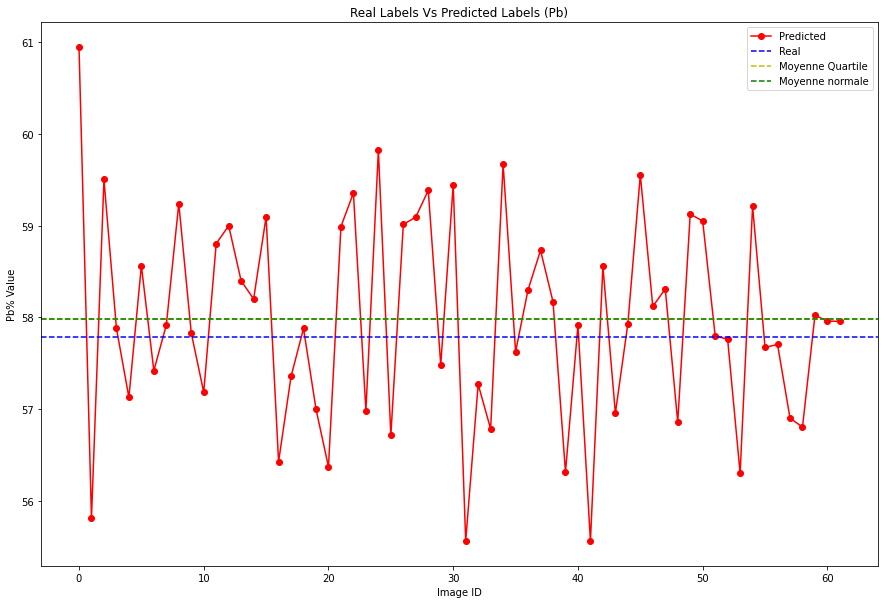

In [97]:
PlotTenneurs(Teneur_predit, TeunneurReel, Moyenne , 'Pb')

In [98]:
TeunneurReel = TenneurReel("rl4_pb12-4.mp4", "DataSource.xlsx")

In [99]:
TeunneurReel

(1.62, 10.95, 49.52, 5.18)

In [100]:
Teneur_predit = []
Fe = []
Cu = []
Pb = []
Zn = []
count = 0

Video = cv2.VideoCapture("./video_test/rl4_pb12-4.mp4")

while(Video.isOpened()):
    Video.set(cv2.CAP_PROP_POS_MSEC,(count*500))    # added this line 
    
    success, frame = Video.read()
    if success == False:
        break
        #offset 200
    image = crop(frame, 200, 200)
    
        
    #prediction
        #resize 400
    # resized = cv2.resize(image, (200,200), interpolation = cv2.INTER_AREA)
    # resized = resized/255.0
    # resized = np.array(resized)
    # resized = resized.reshape((1,200,200,3))
    
    # apply fft
    fft_pca = image_to_fft_pca(image)
    fft_pca = fft_pca.reshape(1, -1)

    #predict
    t = svm.predict(fft_pca)
    
    #print(t)
    
    Teneur_predit.append(t)
        
    count=count+1

In [101]:
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)

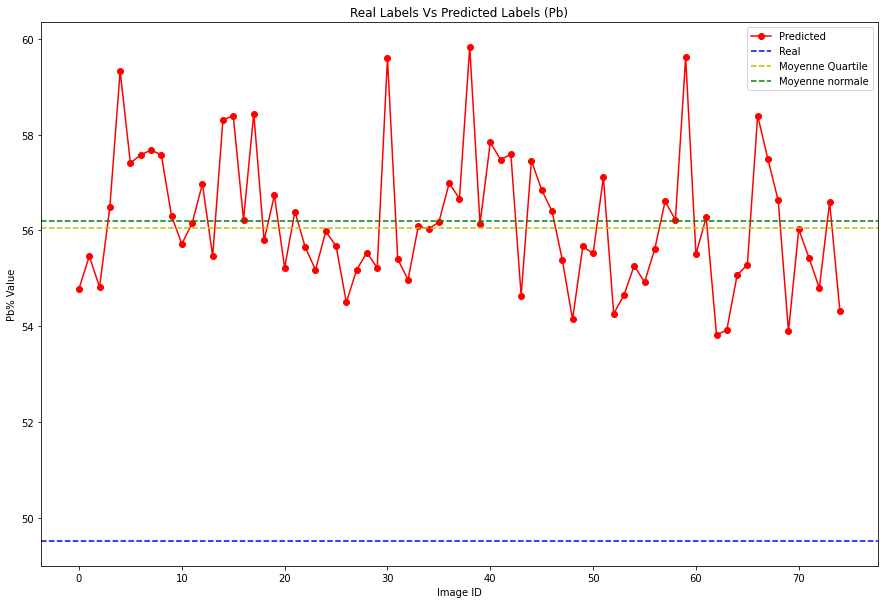

In [102]:
PlotTenneurs(Teneur_predit, TeunneurReel, Moyenne , 'Pb')